## Cluster Analysis Pipeline
- Structural analysis: cluster counts, size distribution, title diversity, date range
- Semantic concept labeling: zero-shot classification to identify relevant visual themes


## 0. Imports

In [1]:
from __future__ import annotations

import json
import math
import random
import re
from datetime import datetime
from io import BytesIO
from pathlib import Path
from typing import Any, Dict, Optional, Sequence
from urllib.error import HTTPError, URLError
from urllib.parse import quote
from urllib.request import Request, urlopen

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output, display
from matplotlib.ticker import MaxNLocator
from PIL import Image
from sentence_transformers import SentenceTransformer
from sklearn.mixture import GaussianMixture

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.11/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


## 1. Configuration

Set core paths, output directories, API base URL, label vocabulary, and zero-shot labeling options.

In [2]:
CLUSTERS_PATH = Path("clusters_min_5.json")
ALL_PHOTOS_TXT = Path("all_photos.txt")
ALL_PHOTOS_NPY = Path("all_photos.npy")

OUT_DIR = Path("concepts")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Cache for raw zero-shot results
RAW_CACHE_JSON = OUT_DIR / "cluster_zero_shot_raw_min5.json"
FORCE_RERUN_RAW = True

# API: serve image data and metadata
API_BASE = "http://localhost:8000"

# Zero shot labels
LABELS = [
    "portrait",
    "group of people",
    "person standing",
    "building",
    "landscape",
    "marketing advertisement",
    "transportation vehicle",
    "animal"
]
PROMPTS = [lab for lab in LABELS]

TOPK = 3
OTHER_LABEL = "Other"

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Gill Sans", "Gill Sans MT", "Gill Sans Std", "DejaVu Sans"]

## 2. Helper functions

In [3]:
def load_json(path: Path) -> Any:
    with open(path, "r") as f:
        return json.load(f)

def save_json(path: Path, obj: Any) -> None:
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def fmt_threshold_for_filename(t: float) -> str:
    # Format threshold value for filenames
    s = f"{t:.6f}".rstrip("0").rstrip(".")
    return s

def ensure_float(x: Any) -> Optional[float]:
    if x is None:
        return None
    try:
        return float(x)
    except Exception:
        return None

def resize_for_display(pil_img: Image.Image, max_w: int = 500, max_h: int = 500) -> Image.Image:
    # Resize image for display
    w, h = pil_img.size
    scale = min(max_w / w, max_h / h, 1.0)
    if scale >= 1.0:
        return pil_img
    new_size = (int(w * scale), int(h * scale))
    return pil_img.resize(new_size, Image.Resampling.LANCZOS)

def floor_to_2_decimals(x: float) -> float:
    return math.floor(x * 100) / 100

def ceil_to_2_decimals(x: float) -> float:
    return math.ceil(x * 100) / 100

def gaussian_pdf(x: np.ndarray, mu: float, sigma: float) -> np.ndarray:
    # Probability density of a Gaussian distribution
    sigma = max(float(sigma), 1e-8)
    return (1.0 / (np.sqrt(2.0 * np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def fit_gmm_threshold(scores_1d: np.ndarray, grid_n: int = 4001) -> Dict[str, Any]:
    """
    Fit a 2-component GMM and return the posterior crossover
    between the low-confidence and high-confidence components.
    """
    x = scores_1d.reshape(-1, 1)

    gmm = GaussianMixture(
        n_components=2,
        covariance_type="full",
        random_state=42,
        n_init=20,
    )
    gmm.fit(x)

    means = gmm.means_.flatten()
    variances = gmm.covariances_.reshape(-1)
    stds = np.sqrt(variances)
    weights = gmm.weights_.flatten()

    order = np.argsort(means)
    means = means[order]
    stds = stds[order]
    weights = weights[order]

    low_mean, high_mean = means
    low_std, high_std = stds
    low_weight, high_weight = weights

    grid = np.linspace(scores_1d.min(), scores_1d.max(), grid_n)

    low_pdf = low_weight * gaussian_pdf(grid, low_mean, low_std)
    high_pdf = high_weight * gaussian_pdf(grid, high_mean, high_std)
    mixture_pdf = low_pdf + high_pdf

    posterior_low = low_pdf / np.maximum(mixture_pdf, 1e-12)
    posterior_high = high_pdf / np.maximum(mixture_pdf, 1e-12)

    idx = np.argmin(np.abs(posterior_low - posterior_high))
    threshold = float(grid[idx])

    return {
        "threshold": threshold,
        "grid": grid,
        "low_pdf": low_pdf,
        "high_pdf": high_pdf,
        "mixture_pdf": mixture_pdf,
        "posterior_low": posterior_low,
        "posterior_high": posterior_high,
        "low_mean": float(low_mean),
        "low_std": float(low_std),
        "low_weight": float(low_weight),
        "high_mean": float(high_mean),
        "high_std": float(high_std),
        "high_weight": float(high_weight),
    }

## 3. Load clusters

Exclude noise (cluster 0).

In [4]:
assert CLUSTERS_PATH.exists(), f"Missing {CLUSTERS_PATH.resolve()}"
clusters_raw = load_json(CLUSTERS_PATH)

clusters = {str(k): v for k, v in clusters_raw.items()}
clusters = {k: v for k, v in clusters.items() if k != "0"}

print(f"Total clusters (excluding 0): {len(clusters)}")
print(f"Total filenames (excluding 0): {sum(len(v) for v in clusters.values())}")
print("Example cluster IDs:", list(clusters.keys())[:10])

Total clusters (excluding 0): 1910
Total filenames (excluding 0): 20753
Example cluster IDs: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']


## 4. Cluster size distribution

Clusters with size <= 20: 1731
Saved histogram to: overall_stats/cluster_size_histogram.png


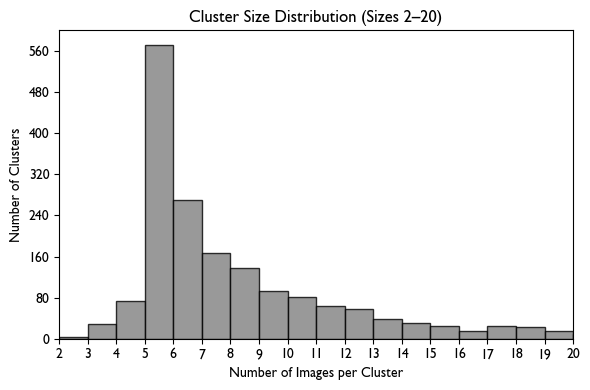

,Cluster size,Count
0,2,3
1,3,28
2,4,73
3,5,572
4,6,271
5,7,167
6,8,137
7,9,93
8,10,81
9,11,64


Clusters with size > 20: 179
Top 10 largest clusters (cluster_id, size):
  1: 499
  2: 271
  3: 197
  4: 168
  5: 140
  6: 113
  7: 104
  8: 103
  9: 97
  10: 95


In [5]:
STATS_DIR = Path("overall_stats")
STATS_DIR.mkdir(parents=True, exist_ok=True)

all_sizes = [len(filenames) for filenames in clusters.values()]

sizes_le_10000 = [s for s in all_sizes if s <= 10000]
excluded = len(all_sizes) - len(sizes_le_10000)

clusters_size_le_20 = sum(1 for s in all_sizes if s <= 20)
clusters_gt_20 = sum(1 for s in all_sizes if s > 20)

print(f"Clusters with size <= 20: {clusters_size_le_20}")

# Zoom in on cluster sizes 2 to 20
sizes_2_20 = [s for s in sizes_le_10000 if 2 <= s <= 20]

fig = plt.figure(figsize=(6, 4))

n, bin_edges, _ = plt.hist(
    sizes_2_20,
    bins=range(2, 22), # bins: [2,3), [3,4), ... , [20,21)
    color="grey",
    edgecolor="black",
    alpha=0.8,
)

plt.xlim(2, 20)
plt.xticks(range(2, 21))
plt.margins(x=0)

max_count = n.max() if len(n) else 0
plt.ylim(0, max_count * 1.05 if max_count > 0 else 1)
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

plt.xlabel("Number of Images per Cluster")
plt.ylabel("Number of Clusters")
plt.title("Cluster Size Distribution (Sizes 2–20)")
plt.tight_layout()

hist_path = STATS_DIR / "cluster_size_histogram.png"
fig.savefig(hist_path, dpi=300, bbox_inches="tight")
print(f"Saved histogram to: {hist_path}")

plt.show()

# Counts table
bin_table = pd.DataFrame(
    {
        "Cluster size": list(range(2, 21)),
        "Count": [int(n[i]) for i in range(0, 19)],
    }
)
display(bin_table)

print(f"Clusters with size > 20: {clusters_gt_20}")

top10 = sorted(((cid, len(files)) for cid, files in clusters.items()), key=lambda x: -x[1])[:10]
print("Top 10 largest clusters (cluster_id, size):")
for cid, size in top10:
    print(f"  {cid}: {size}")

## 5. Align filenames and embeddings

In [6]:
assert ALL_PHOTOS_TXT.exists(), f"Missing {ALL_PHOTOS_TXT.resolve()}"
assert ALL_PHOTOS_NPY.exists(), f"Missing {ALL_PHOTOS_NPY.resolve()}"

needed = set()
for fnames in clusters.values():
    needed.update(fnames)

name_to_orig_row = {}
with open(ALL_PHOTOS_TXT, "r") as f:
    for orig_row, line in enumerate(f):
        name = line.strip()
        if name and name in needed:
            name_to_orig_row[name] = orig_row

names_in_order = sorted(name_to_orig_row.keys(), key=lambda n: name_to_orig_row[n])
filename_to_row = {name: i for i, name in enumerate(names_in_order)}

missing = len(needed) - len(names_in_order)
print("Needed filenames:", len(needed))
print("Found in all_photos.txt:", len(names_in_order))
print("Missing from all_photos.txt:", missing)

orig_rows = np.array([name_to_orig_row[n] for n in names_in_order], dtype=np.int64)

Needed filenames: 20753
Found in all_photos.txt: 20753
Missing from all_photos.txt: 0


In [7]:
emb_mem = np.load(ALL_PHOTOS_NPY, mmap_mode="r")  
embeddings = np.asarray(emb_mem[orig_rows], dtype=np.float32)  

norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
norms[norms == 0] = 1.0
embeddings_norm = embeddings / norms

print("embeddings_norm shape:", embeddings_norm.shape)

embeddings_norm shape: (20753, 512)


## 6. Load CLIP, embed text concept labels

In [8]:
print("Loading model: sentence-transformers/clip-ViT-B-32")
clip_model = SentenceTransformer("clip-ViT-B-32")

print("Text embedding dim:", clip_model.get_sentence_embedding_dimension())

text_vecs = clip_model.encode(
    PROMPTS,
    convert_to_numpy=True,
    normalize_embeddings=True,
).astype(np.float32)

print("text_vecs shape:", text_vecs.shape)

Loading model: sentence-transformers/clip-ViT-B-32
Text embedding dim: None
text_vecs shape: (8, 512)


## 7. Generate top-k zero-shot labels per cluster

For each cluster:
- Average the normalized image embeddings, 
- Compare resulting cluster representation to the label embeddings
- Store the top-k matches

In [9]:
def topk_labels_for_vector(img_vec_norm: np.ndarray, text_vecs_norm: np.ndarray, labels: Sequence[str], k: int = 3):
    scores = text_vecs_norm @ img_vec_norm
    top_idx = np.argsort(-scores)[:k]
    return [(labels[i], float(scores[i])) for i in top_idx]

if RAW_CACHE_JSON.exists() and not FORCE_RERUN_RAW:
    print(f"Loading RAW cache: {RAW_CACHE_JSON}")
    raw_results = load_json(RAW_CACHE_JSON)
else:
    print("Computing RAW per-cluster results")
    raw_results = {}

    for cid, fnames in clusters.items():
        idxs = []
        unmapped = 0
        for name in fnames:
            row = filename_to_row.get(name)
            if row is None:
                unmapped += 1
            else:
                idxs.append(row)

        if len(idxs) == 0:
            raw_results[cid] = {
                "cluster_id": cid,
                "n_total": len(fnames),
                "n_mapped": 0,
                "n_unmapped": unmapped,
                "topk": [],
                "top1_label_raw": None,
                "top1_score_raw": None,
            }
            continue

        v = embeddings_norm[idxs].mean(axis=0)
        vn = float(np.linalg.norm(v))
        if vn != 0:
            v = v / vn

        topk = topk_labels_for_vector(v, text_vecs, LABELS, k=TOPK)
        top1_label_raw, top1_score_raw = topk[0]

        raw_results[cid] = {
            "cluster_id": cid,
            "n_total": len(fnames),
            "n_mapped": len(idxs),
            "n_unmapped": unmapped,
            "topk": topk,
            "top1_label_raw": top1_label_raw,
            "top1_score_raw": top1_score_raw,
        }

    print(f"Saving RAW cache: {RAW_CACHE_JSON}")
    save_json(RAW_CACHE_JSON, raw_results)

some = list(raw_results.items())[:3]
some

Computing RAW per-cluster results
Saving RAW cache: concepts/cluster_zero_shot_raw_min5.json


[('1',
  {'cluster_id': '1',
   'n_total': 499,
   'n_mapped': 499,
   'n_unmapped': 0,
   'topk': [('portrait', 0.24585828185081482),
    ('marketing advertisement', 0.22327680885791779),
    ('person standing', 0.2189224660396576)],
   'top1_label_raw': 'portrait',
   'top1_score_raw': 0.24585828185081482}),
 ('2',
  {'cluster_id': '2',
   'n_total': 271,
   'n_mapped': 271,
   'n_unmapped': 0,
   'topk': [('portrait', 0.24858330190181732),
    ('marketing advertisement', 0.23014357686042786),
    ('person standing', 0.21649613976478577)],
   'top1_label_raw': 'portrait',
   'top1_score_raw': 0.24858330190181732}),
 ('3',
  {'cluster_id': '3',
   'n_total': 197,
   'n_mapped': 197,
   'n_unmapped': 0,
   'topk': [('portrait', 0.23459579050540924),
    ('marketing advertisement', 0.22726485133171082),
    ('person standing', 0.2209288626909256)],
   'top1_label_raw': 'portrait',
   'top1_score_raw': 0.23459579050540924})]

## 8. Estimate optimal Other threshold using GMM
Use the raw top-1 cosine similarity scores to estimate an optimal threshold for assigning to the "Other" category. Candidate threshold are:
- the optimal GMM value
- the floor of the optimal value to 2 decimal places
- the ceiling of the optimal value to 2 decimal places

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Optimal threshold: 0.2485
Floor to 2 decimals: 0.24
Ceiling to 2 decimals: 0.25
Thresholds to try: ['0.248466', '0.24', '0.25']

Low-confidence component:
mean=0.2450, std=0.0130, weight=0.3729
High-confidence component:
mean=0.2605, std=0.0087, weight=0.6271


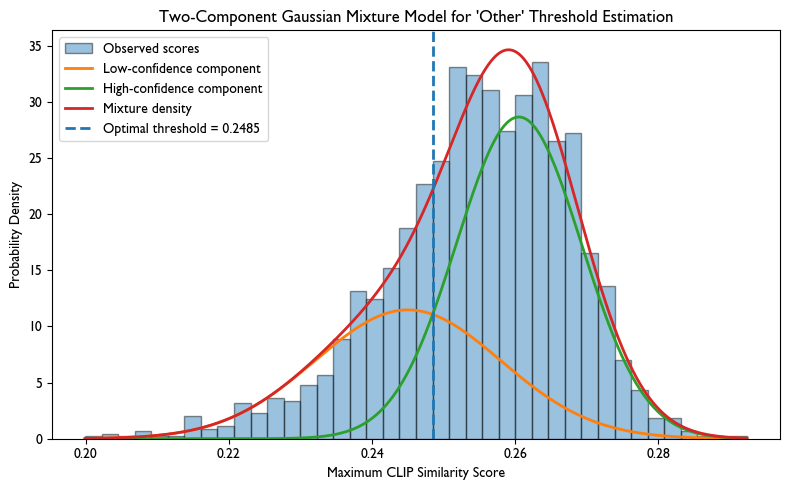

In [10]:
scores = np.array(
    [
        r.get("top1_score_raw")
        for r in raw_results.values()
        if r.get("top1_score_raw") is not None
    ],
    dtype=np.float64,
)
scores = np.clip(scores, -1.0, 1.0)

gmm_result = fit_gmm_threshold(scores)
OTHER_THRESHOLD_GMM = gmm_result["threshold"]
OTHER_THRESHOLD_FLOOR = floor_to_2_decimals(OTHER_THRESHOLD_GMM)
OTHER_THRESHOLD_CEIL = ceil_to_2_decimals(OTHER_THRESHOLD_GMM)

THRESHOLDS_TO_TRY = [OTHER_THRESHOLD_GMM, OTHER_THRESHOLD_FLOOR, OTHER_THRESHOLD_CEIL]

print(f"Optimal threshold: {OTHER_THRESHOLD_GMM:.4f}")
print(f"Floor to 2 decimals: {OTHER_THRESHOLD_FLOOR:.2f}")
print(f"Ceiling to 2 decimals: {OTHER_THRESHOLD_CEIL:.2f}")
print("Thresholds to try:", [fmt_threshold_for_filename(t) for t in THRESHOLDS_TO_TRY])
print()
print("Low-confidence component:")
print(
    f"mean={gmm_result['low_mean']:.4f}, "
    f"std={gmm_result['low_std']:.4f}, "
    f"weight={gmm_result['low_weight']:.4f}"
)
print("High-confidence component:")
print(
    f"mean={gmm_result['high_mean']:.4f}, "
    f"std={gmm_result['high_std']:.4f}, "
    f"weight={gmm_result['high_weight']:.4f}"
)

fig = plt.figure(figsize=(8, 5))
plt.hist(scores, bins=40, density=True, alpha=0.45, edgecolor="black", label="Observed scores")
plt.plot(gmm_result["grid"], gmm_result["low_pdf"], linewidth=2, label="Low-confidence component")
plt.plot(gmm_result["grid"], gmm_result["high_pdf"], linewidth=2, label="High-confidence component")
plt.plot(gmm_result["grid"], gmm_result["mixture_pdf"], linewidth=2, label="Mixture density")
plt.axvline(
    OTHER_THRESHOLD_GMM,
    linestyle="--",
    linewidth=2,
    label=f"Optimal threshold = {OTHER_THRESHOLD_GMM:.4f}",
)

plt.xlabel("Maximum CLIP Similarity Score")
plt.ylabel("Probability Density")
plt.title("Two-Component Gaussian Mixture Model for 'Other' Threshold Estimation")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Apply candidate thresholds and save outputs

In [11]:
def apply_threshold_to_raw(raw_results: Dict[str, Dict[str, Any]], threshold: float, other_label: str) -> Dict[str, Dict[str, Any]]:
    out = {}
    for cid, r in raw_results.items():
        score = ensure_float(r.get("top1_score_raw"))
        raw_lab = r.get("top1_label_raw")

        assigned = other_label
        if score is not None and raw_lab is not None and score >= threshold:
            assigned = str(raw_lab)

        out[cid] = {
            **r,
            "other_threshold": threshold,
            "top1_label": assigned,
            "top1_score": score,
        }
    return out

def results_to_df(results: Dict[str, Dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for cid, r in results.items():
        topk = r.get("topk") or []

        def fmt(i: int) -> str:
            if i >= len(topk):
                return ""
            lab, sc = topk[i]
            return f"{lab} ({float(sc):.3f})"

        rows.append({
            "cluster_id": str(cid),
            "n_total": r.get("n_total"),
            "n_mapped": r.get("n_mapped"),
            "n_unmapped": r.get("n_unmapped"),
            "top1_assigned": r.get("top1_label", ""),
            "top1_raw": r.get("top1_label_raw", ""),
            "top1_score": ensure_float(r.get("top1_score_raw")),
            "top1": fmt(0),
            "top2": fmt(1),
            "top3": fmt(2),
        })

    df = pd.DataFrame(rows)
    df["cluster_id_num"] = pd.to_numeric(df["cluster_id"], errors="coerce")
    df = df.sort_values(["n_mapped", "cluster_id_num"], ascending=[False, True]).drop(columns=["cluster_id_num"])
    return df

written = []
for t in THRESHOLDS_TO_TRY:
    t_str = f"{t:.6f}".rstrip("0").rstrip(".")
    t_dir = OUT_DIR / t_str
    t_dir.mkdir(parents=True, exist_ok=True)

    out_json = t_dir / "cluster_zero_shot_results_min5.json"
    out_csv  = t_dir / "cluster_zero_shot_results_min5.csv"

    results_t = apply_threshold_to_raw(raw_results, threshold=t, other_label=OTHER_LABEL)
    df_t = results_to_df(results_t)

    save_json(out_json, results_t)
    df_t.to_csv(out_csv, index=False)

    written.append((t, t_dir, out_json, out_csv))
    print(f"[thr={t_str}] Wrote {out_json} + {out_csv} | rows={len(df_t)}")

written

[thr=0.248466] Wrote concepts/0.248466/cluster_zero_shot_results_min5.json + concepts/0.248466/cluster_zero_shot_results_min5.csv | rows=1910
[thr=0.24] Wrote concepts/0.24/cluster_zero_shot_results_min5.json + concepts/0.24/cluster_zero_shot_results_min5.csv | rows=1910
[thr=0.25] Wrote concepts/0.25/cluster_zero_shot_results_min5.json + concepts/0.25/cluster_zero_shot_results_min5.csv | rows=1910


[(0.2484657553769648,
  PosixPath('concepts/0.248466'),
  PosixPath('concepts/0.248466/cluster_zero_shot_results_min5.json'),
  PosixPath('concepts/0.248466/cluster_zero_shot_results_min5.csv')),
 (0.24,
  PosixPath('concepts/0.24'),
  PosixPath('concepts/0.24/cluster_zero_shot_results_min5.json'),
  PosixPath('concepts/0.24/cluster_zero_shot_results_min5.csv')),
 (0.25,
  PosixPath('concepts/0.25'),
  PosixPath('concepts/0.25/cluster_zero_shot_results_min5.json'),
  PosixPath('concepts/0.25/cluster_zero_shot_results_min5.csv'))]

## 10. Select threshold output and inspect concept distributions

In [12]:
csvs = sorted(OUT_DIR.glob("*/cluster_zero_shot_results_min5.csv"))
assert csvs, f"No threshold CSVs found under {OUT_DIR.resolve()} (expected concepts/<thr>/cluster_zero_shot_results_min5.csv)"

threshold_dropdown = widgets.Dropdown(
    options=[str(p.parent.name) for p in csvs],
    value=str(csvs[0].parent.name),
    description="Threshold:",
    layout=widgets.Layout(width="450px"),
    style={"description_width": "140px"},
)

use_btn = widgets.Button(description="Use this threshold", button_style="primary")
chosen_out = widgets.Output()

chosen = {"thr_str": threshold_dropdown.value, "csv_path": OUT_DIR / threshold_dropdown.value / "cluster_zero_shot_results_min5.csv"}

def on_choose(_):
    chosen["thr_str"] = threshold_dropdown.value
    chosen["csv_path"] = OUT_DIR / chosen["thr_str"] / "cluster_zero_shot_results_min5.csv"
    with chosen_out:
        clear_output(wait=True)
        print("Selected threshold folder:", chosen["thr_str"])
        print("CSV:", chosen["csv_path"])

use_btn.on_click(on_choose)

display(widgets.VBox([threshold_dropdown, use_btn, chosen_out]))

Using threshold: 0.24
CSV: concepts/0.24/cluster_zero_shot_results_min5.csv
JSON: concepts/0.24/cluster_zero_shot_results_min5.json


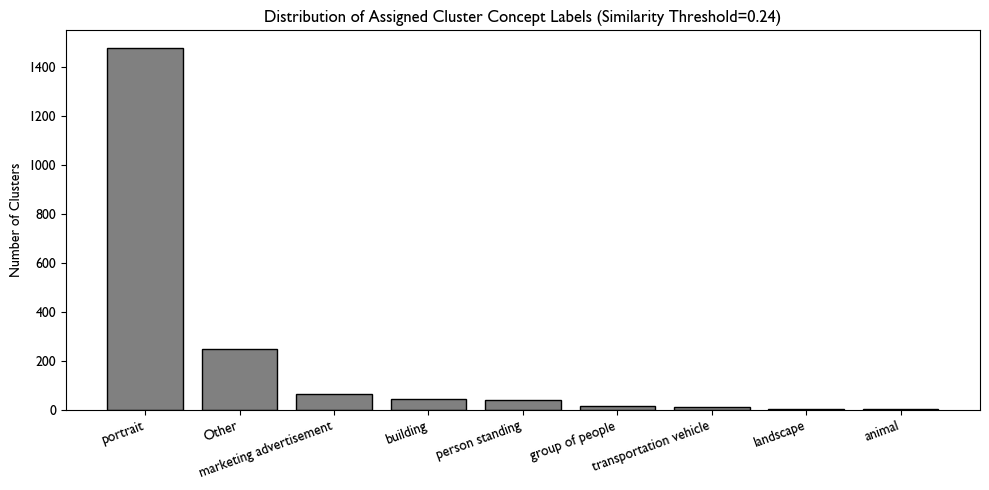

Saved plot: concepts/0.24/concept_distribution_hist.png


top1_assigned
portrait                   1477
Other                       248
marketing advertisement      64
building                     46
person standing              42
group of people              17
transportation vehicle       10
landscape                     3
animal                        3
Name: count, dtype: int64

In [13]:
chosen_thr_str = chosen["thr_str"]
chosen_dir = OUT_DIR / chosen_thr_str
chosen_csv = chosen["csv_path"]

df = pd.read_csv(chosen_csv, dtype={"cluster_id": str})

chosen_json = chosen_dir / "cluster_zero_shot_results_min5.json"
cluster_results = load_json(chosen_json) if chosen_json.exists() else {}

chosen_thr = float(chosen_thr_str)
print("Using threshold:", chosen_thr_str)
print("CSV:", chosen_csv)
print("JSON:", chosen_json)

counts = df["top1_assigned"].value_counts()

fig = plt.figure(figsize=(10, 5))
plt.bar(
    counts.index.astype(str),
    counts.values,
    color="gray",
    edgecolor="black",
    linewidth=1
)

plt.xticks(rotation=20, ha="right")
plt.ylabel("Number of Clusters")
plt.title(f"Distribution of Assigned Cluster Concept Labels (Similarity Threshold={chosen_thr_str})")

plt.tight_layout()
plt.show()

plot_path = chosen_dir / "concept_distribution_hist.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
print("Saved plot:", plot_path)

counts.head(15)

## 11. Concept distribution summary table


In [14]:
rows = []

for cid, row in df.iterrows():
    label = row["top1_assigned"]
    cluster_id = str(row["cluster_id"])

    n_images = len(clusters.get(cluster_id, []))

    rows.append({
        "cluster_id": cluster_id,
        "category label": label,
        "n_images": n_images
    })

df_totals = pd.DataFrame(rows)

total_clusters = len(df_totals)
total_images = df_totals["n_images"].sum()

summary = (
    df_totals
    .groupby("category label", as_index=False)
    .agg(
        n_clusters=("cluster_id", "count"),
        total_images=("n_images", "sum")
    )
)

summary["% of clusters with this top1 category"] = (
    summary["n_clusters"] / total_clusters * 100
)

summary["% of total images"] = (
    summary["total_images"] / total_images * 100
)

summary = (
    summary[
        [
            "category label",
            "n_clusters",
            "% of clusters with this top1 category",
            "total_images",
            "% of total images",
        ]
    ]
    .rename(
        columns={
            "n_clusters": "# clusters",
            "total_images": "# total images summed from those clusters",
        }
    )
    .sort_values(
        by="% of clusters with this top1 category",
        ascending=False,
    )
    .reset_index(drop=True)
)

summary_display = summary.copy()
summary_display["% of clusters with this top1 category"] = (
    summary_display["% of clusters with this top1 category"].round(2)
)
summary_display["% of total images"] = (
    summary_display["% of total images"].round(2)
)

display(summary_display)

summary_path = chosen_dir / "concept_summary_table.csv"
summary.to_csv(summary_path, index=False)
print("Saved summary table:", summary_path)

,category label,# clusters,% of clusters with this top1 category,# total images summed from those clusters,% of total images
0,portrait,1477,77.33,16406,79.05
1,Other,248,12.98,2520,12.14
2,marketing advertisement,64,3.35,558,2.69
3,building,46,2.41,613,2.95
4,person standing,42,2.20,252,1.21
5,group of people,17,0.89,159,0.77
6,transportation vehicle,10,0.52,90,0.43
7,animal,3,0.16,34,0.16
8,landscape,3,0.16,121,0.58


Saved summary table: concepts/0.24/concept_summary_table.csv


## 12. Interactive visualizers


In [15]:
def fetch_image_info(image_id: str) -> Dict[str, Any]:
    url = f"{API_BASE.rstrip('/')}/api/image/{image_id}"
    req = Request(url, method="GET")
    try:
        with urlopen(req, timeout=15) as resp:
            return json.loads(resp.read().decode())
    except HTTPError as e:
        raise RuntimeError(f"HTTP {e.code} for {url}")
    except URLError as e:
        raise RuntimeError(f"Connection error: {e.reason}")

def fetch_image_bytes(image_url: str) -> bytes:
    req = Request(image_url, headers={"User-Agent": "Mozilla/5.0"})
    try:
        with urlopen(req, timeout=30) as resp:
            return resp.read()
    except HTTPError as e:
        raise RuntimeError(f"HTTP {e.code} when downloading image: {image_url}")
    except URLError as e:
        raise RuntimeError(f"Connection error downloading image: {e.reason}")

### 12.1 Single-image fetcher

Inspect one image either by cluster ID + image index, or by directly entering a filename/image ID.

In [16]:
LABEL_W = "200px"
FIELD_W = "420px"
FULL_W = "760px"

cluster_id_box = widgets.Textarea(
    value="1",
    description="Enter Cluster ID:",
    style={"description_width": LABEL_W},
    layout=widgets.Layout(width=FIELD_W, height="30px"),
)

image_index_box = widgets.BoundedIntText(
    value=0,
    min=0,
    max=10_000_000,
    step=1,
    description="Enter Image Index:",
    style={"description_width": LABEL_W},
    layout=widgets.Layout(width=FIELD_W),
)

divider = widgets.HTML(value="<hr style='margin:10px 0; border:1px solid #ddd;'>")

filename_box = widgets.Textarea(
    value="",
    description="Enter filename:",
    placeholder="Optional: paste image_id/filename to override cluster+index selection",
    style={"description_width": LABEL_W},
    layout=widgets.Layout(width=FULL_W, height="40px"),
)

max_w_box = widgets.BoundedIntText(
    value=420, min=200, max=3000, step=50,
    description="Max width:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="260px"),
)
max_h_box = widgets.BoundedIntText(
    value=420, min=200, max=3000, step=50,
    description="Max height:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="260px"),
)

fetch_btn = widgets.Button(description="Fetch", button_style="primary")

out_pred = widgets.Output()
out_url = widgets.Output()
out_img = widgets.Output()

def resolve_image_id(cluster_id: str, idx: int, typed_filename: str) -> str:
    typed_filename = (typed_filename or "").strip()
    if typed_filename:
        return typed_filename

    key = str(cluster_id).strip()
    if key not in clusters:
        raise KeyError(f"Cluster '{key}' not found.")
    arr = clusters[key]
    if len(arr) == 0:
        raise IndexError(f"Cluster '{key}' is empty.")
    if idx < 0 or idx >= len(arr):
        raise IndexError(f"Index {idx} out of range for cluster '{key}' (size={len(arr)}).")
    return arr[idx]

def render_predictions(cluster_id: str) -> None:
    r = cluster_results.get(str(cluster_id))
    with out_pred:
        clear_output(wait=True)
        if not r:
            print("No predictions found for this cluster in the selected threshold file.")
            return

        print(f"Cluster {cluster_id} | mapped {r['n_mapped']}/{r['n_total']} | unmapped={r['n_unmapped']}")
        top1_raw = r.get("top1_label_raw")
        top1_score = r.get("top1_score_raw")
        assigned = r.get("top1_label")
        if top1_score is not None:
            print(f"Top-1 assigned: {assigned} (raw: {top1_raw}, score={float(top1_score):.3f})")
        else:
            print(f"Top-1 assigned: {assigned} (raw: {top1_raw}, score=None)")

        print("Top-3:")
        for lab, sc in (r.get("topk") or []):
            print(f"  - {lab}: {float(sc):.3f}")

def do_fetch(_=None):
    with out_url: clear_output(wait=True)
    with out_img: clear_output(wait=True)

    cid = str(cluster_id_box.value).strip()
    idx = int(image_index_box.value)
    typed = filename_box.value

    render_predictions(cid)

    try:
        image_id = resolve_image_id(cid, idx, typed)
    except Exception as e:
        with out_url:
            print(f"Selection error: {e}")
        return

    try:
        info = fetch_image_info(quote(image_id, safe=""))
    except Exception as e:
        with out_url:
            print(f"Metadata fetch failed: {e}")
        return

    img_url = info.get("url")
    with out_url:
        print(img_url if img_url else "(No image URL returned)")

    if not img_url:
        return

    try:
        b = fetch_image_bytes(img_url)
        im = Image.open(BytesIO(b))
        im_disp = resize_for_display(im, max_w=max_w_box.value, max_h=max_h_box.value)
        with out_img:
            display(im_disp)
    except Exception as e:
        with out_img:
            print(f"Image render failed: {e}")

fetch_btn.on_click(do_fetch)

ui = widgets.VBox([
    cluster_id_box,
    image_index_box,
    divider,
    filename_box,
    widgets.HBox([max_w_box, max_h_box, fetch_btn]),
    out_pred,
    out_url,
    out_img,
])
display(ui)

do_fetch()

### 12.2 Concept-based cluster sampling grid

Sample clusters by semantic label and display representative images in a grid (one per cluster).

In [17]:
def pil_to_widget(img: Image.Image, format="PNG"):
    buf = BytesIO()
    img.save(buf, format=format)
    return widgets.Image(
        value=buf.getvalue(),
        format=format.lower(),
        layout=widgets.Layout(margin="5px")
    )

concept_dropdown = widgets.Dropdown(
    options=sorted(df["top1_assigned"].unique()),
    description="Concept:",
    layout=widgets.Layout(width="350px"),
)

sample_btn = widgets.Button(description="Sample Images", button_style="primary")
out_images = widgets.Output()


def sample_images(_=None):
    concept = concept_dropdown.value

    concept_cluster_ids = (
        df[df["top1_assigned"] == concept]["cluster_id"]
        .astype(str)
        .tolist()
    )

    with out_images:
        clear_output(wait=True)

        if not concept_cluster_ids:
            print("No clusters found for this concept.")
            return

        random.shuffle(concept_cluster_ids)

        picked_widgets = []
        picked = 0
        tries = 0
        max_clusters = 25

        while picked < max_clusters and tries < len(concept_cluster_ids):

            cid = concept_cluster_ids[tries]
            tries += 1

            cluster_images = clusters.get(cid)

            if not cluster_images:
                continue

            img_id = cluster_images[0]

            try:
                info = fetch_image_info(quote(img_id, safe=""))
                url = info.get("url")

                if not url:
                    continue

                b = fetch_image_bytes(url)
                im = Image.open(BytesIO(b))

                im_disp = resize_for_display(im, max_w=250, max_h=250)

                picked_widgets.append(pil_to_widget(im_disp))
                picked += 1

            except Exception:
                continue

        if not picked_widgets:
            print(f"No images could be loaded for concept '{concept}'.")
            return

        cols = 7

        rows = [
            widgets.HBox(picked_widgets[i:i+cols])
            for i in range(0, len(picked_widgets), cols)
        ]

        display(widgets.VBox(rows))

        print(
            f"Displayed {picked} clusters for concept '{concept}'. "
            f"(attempted {tries})"
        )

sample_btn.on_click(sample_images)

display(widgets.VBox([concept_dropdown, sample_btn, out_images]))

## 13. Fetch metadata for downstream analyses

In [18]:
API_BASE_FOR_METADATA = "http://localhost:8000"
CLUSTERS_JSON = Path("clusters_min_5.json")
OUT_METADATA_JSON = Path("metadata.json")
OUT_ERRORS_JSON = Path("metadata_errors.json")

assert CLUSTERS_JSON.exists(), f"Missing {CLUSTERS_JSON.resolve()}"

with open(CLUSTERS_JSON, "r") as f:
    clusters_for_metadata = json.load(f)

clusters_for_metadata = {str(k): v for k, v in clusters_for_metadata.items() if str(k) != "0"}

seen = set()
all_image_ids = []
for ids in clusters_for_metadata.values():
    for img_id in ids:
        if img_id not in seen:
            seen.add(img_id)
            all_image_ids.append(img_id)

print(f"Total unique image IDs to fetch: {len(all_image_ids)}")


def fetch_image_info_for_metadata(image_id: str) -> dict:
    """
    Fetch a single image's metadata from the FastAPI backend.
    Returns either metadata dict or an {"error": ...} dict.
    """
    url = f"{API_BASE_FOR_METADATA.rstrip('/')}/api/image/{quote(image_id, safe='')}"
    req = Request(url, method="GET")

    try:
        with urlopen(req, timeout=30) as resp:
            payload = resp.read().decode()
            return json.loads(payload)

    except HTTPError as e:
        # record error and continue
        return {"image_id": image_id, "error_type": "HTTPError", "status": e.code, "url": url}

    except URLError as e:
        return {"image_id": image_id, "error_type": "URLError", "reason": str(e.reason), "url": url}

    except Exception as e:
        return {"image_id": image_id, "error_type": "Exception", "reason": str(e), "url": url}


records = []
errors = []

total = len(all_image_ids)
for i, img_id in enumerate(all_image_ids, start=1):
    info = fetch_image_info_for_metadata(img_id)

    if isinstance(info, dict) and "error_type" in info:
        errors.append(info)
    else:
        records.append(info)

    if i % 1000 == 0 or i == total:
        print(f"Fetched {i}/{total} | ok: {len(records)} | errors: {len(errors)}")


OUT_METADATA_JSON.write_text(json.dumps(records, indent=2))
OUT_ERRORS_JSON.write_text(json.dumps(errors, indent=2))

print(f"\nWrote {len(records)} metadata records.")
print(f"Wrote {len(errors)} error records.")

print("\nCoverage summary:")
print("total unique cluster image IDs:", total)
print("ok:", len(records), f"({len(records)/max(total,1)*100:.2f}%)")
print("errors:", len(errors), f"({len(errors)/max(total,1)*100:.2f}%)")

Total unique image IDs to fetch: 20753
Fetched 1000/20753 | ok: 1000 | errors: 0
Fetched 2000/20753 | ok: 2000 | errors: 0
Fetched 3000/20753 | ok: 3000 | errors: 0
Fetched 4000/20753 | ok: 4000 | errors: 0
Fetched 5000/20753 | ok: 4965 | errors: 35
Fetched 6000/20753 | ok: 5937 | errors: 63
Fetched 7000/20753 | ok: 6937 | errors: 63
Fetched 8000/20753 | ok: 7937 | errors: 63
Fetched 9000/20753 | ok: 8937 | errors: 63
Fetched 10000/20753 | ok: 9921 | errors: 79
Fetched 11000/20753 | ok: 10908 | errors: 92
Fetched 12000/20753 | ok: 11908 | errors: 92
Fetched 13000/20753 | ok: 12881 | errors: 119
Fetched 14000/20753 | ok: 13881 | errors: 119
Fetched 15000/20753 | ok: 14873 | errors: 127
Fetched 16000/20753 | ok: 15857 | errors: 143
Fetched 17000/20753 | ok: 16857 | errors: 143
Fetched 18000/20753 | ok: 17835 | errors: 165
Fetched 19000/20753 | ok: 18823 | errors: 177
Fetched 20000/20753 | ok: 19818 | errors: 182
Fetched 20753/20753 | ok: 20570 | errors: 183

Wrote 20570 metadata records.

## 14. Cluster date range analysis

Span between the earliest and latest publication dates represented inside each cluster.


Clusters with valid dates: 1895
Missing/invalid dates (image-level): 183


,cluster_id,n_images_with_dates,start_date,end_date,span_days
0,1,499,1934-02-13,1936-05-26,834
1,2,271,1933-06-14,1934-08-21,434
2,3,197,1914-03-19,1918-04-19,1493
3,4,168,1918-07-17,1922-09-24,1531
4,5,140,1904-03-18,1910-12-09,2458



Top 10 clusters with the longest date ranges:


,cluster_id,n_images_with_dates,start_date,end_date,span_days
0,879,7,1904-11-17,1947-06-27,15563
1,1864,4,1907-09-03,1948-02-15,14776
2,235,17,1905-03-11,1941-07-26,13287
3,1399,5,1909-05-14,1945-02-12,13059
4,1221,4,1915-10-28,1950-10-01,12758
5,1493,5,1911-12-26,1945-11-21,12385
6,1040,6,1911-03-04,1944-10-01,12266
7,153,23,1903-07-03,1936-02-26,11927
8,1346,5,1916-05-13,1948-06-12,11719
9,1861,4,1913-12-30,1945-08-17,11554


Saved: overall_stats/cluster_date_range_hist_zoom_0_380.png


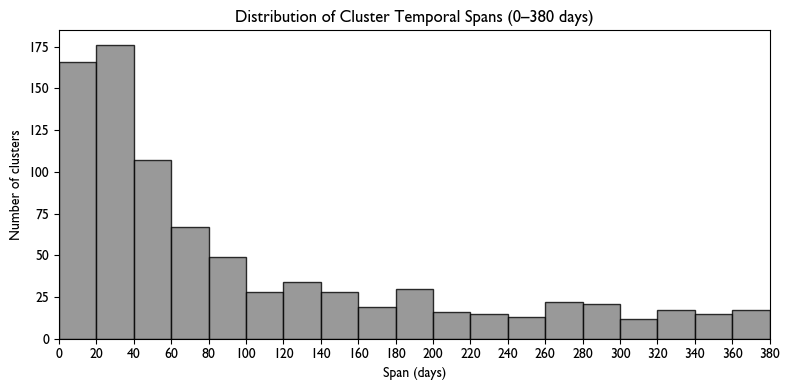


Zoomed histogram (0–380 days, 20-day bins) — bin counts:
  [0, 20): 166
  [20, 40): 176
  [40, 60): 107
  [60, 80): 67
  [80, 100): 49
  [100, 120): 28
  [120, 140): 34
  [140, 160): 28
  [160, 180): 19
  [180, 200): 30
  [200, 220): 16
  [220, 240): 15
  [240, 260): 13
  [260, 280): 22
  [280, 300): 21
  [300, 320): 12
  [320, 340): 17
  [340, 360): 15
  [360, 380): 17
Saved: overall_stats/cluster_date_range_hist_full.png


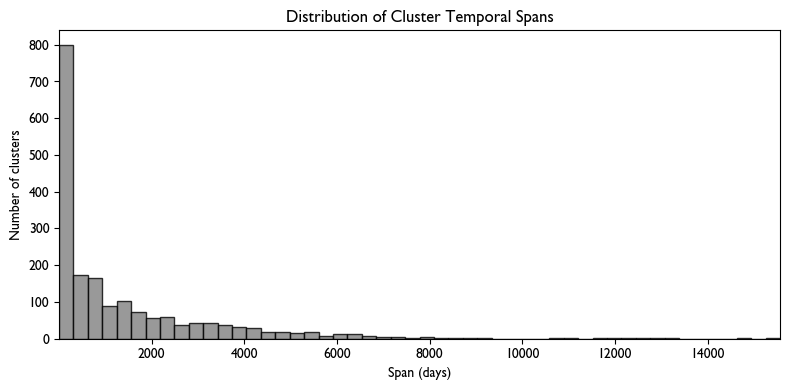


Full histogram — bin counts:
  [1, 312): 799
  [312, 623): 173
  [623, 935): 165
  [935, 1246): 90
  [1246, 1557): 103
  [1557, 1868): 73
  [1868, 2180): 56
  [2180, 2491): 60
  [2491, 2802): 38
  [2802, 3113): 43
  [3113, 3425): 44
  [3425, 3736): 38
  [3736, 4047): 31
  [4047, 4358): 30
  [4358, 4670): 18
  [4670, 4981): 18
  [4981, 5292): 16
  [5292, 5603): 18
  [5603, 5915): 7
  [5915, 6226): 14
  [6226, 6537): 13
  [6537, 6848): 7
  [6848, 7160): 6
  [7160, 7471): 4
  [7471, 7782): 1
  [7782, 8093): 4
  [8093, 8404): 3
  [8404, 8716): 3
  [8716, 9027): 3
  [9027, 9338): 3
  [9338, 9649): 0
  [9649, 9961): 0
  [9961, 10272): 0
  [10272, 10583): 0
  [10583, 10894): 2
  [10894, 11206): 1
  [11206, 11517): 0
  [11517, 11828): 3
  [11828, 12139): 1
  [12139, 12451): 2
  [12451, 12762): 1
  [12762, 13073): 1
  [13073, 13384): 1
  [13384, 13696): 0
  [13696, 14007): 0
  [14007, 14318): 0
  [14318, 14629): 0
  [14629, 14941): 1
  [14941, 15252): 0
  [15252, 15563): 1


In [19]:
CLUSTERS_PATH = Path("clusters_min_5.json")
METADATA_PATH = Path("metadata.json")
STATS_DIR = Path("overall_stats")
STATS_DIR.mkdir(parents=True, exist_ok=True)

with open(CLUSTERS_PATH, "r") as f:
    clusters = json.load(f)

clusters = {str(k): v for k, v in clusters.items() if str(k) != "0"}

with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

id_to_date = {}
for item in metadata:
    img_id = item.get("id")
    d = item.get("date")
    if img_id and d:
        id_to_date[img_id] = d

def parse_date(s):
    try:
        return datetime.strptime(s, "%Y-%m-%d")
    except (ValueError, TypeError):
        return None

rows = []
missing_date = 0

for cid, files in clusters.items():
    dates = []

    for img_id in files:
        d = id_to_date.get(img_id)
        if not d:
            missing_date += 1
            continue

        parsed = parse_date(d)
        if parsed:
            dates.append(parsed)
        else:
            missing_date += 1

    if not dates:
        continue

    start_date = min(dates)
    end_date = max(dates)
    span_days = (end_date - start_date).days + 1

    rows.append({
        "cluster_id": str(cid),
        "n_images_with_dates": len(dates),
        "start_date": start_date,
        "end_date": end_date,
        "span_days": span_days,
    })

cluster_dates_df = pd.DataFrame(rows)

print("Clusters with valid dates:", len(cluster_dates_df))
print("Missing/invalid dates (image-level):", missing_date)

display(cluster_dates_df.head())

# Top 10 longest cluster date ranges
top10_longest = (
    cluster_dates_df
    .sort_values("span_days", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print("\nTop 10 clusters with the longest date ranges:")
display(top10_longest)

# Zoomed histogram (0-380 days)
bins = list(range(0, 381, 20))
counts, edges = np.histogram(cluster_dates_df["span_days"], bins=bins)

fig1 = plt.figure(figsize=(8, 4))
plt.hist(
    cluster_dates_df["span_days"],
    bins=bins,
    color="grey",
    edgecolor="black",
    alpha=0.8
)

plt.xlim(0, 380)
plt.xticks(bins)
plt.margins(x=0)
plt.xlabel("Span (days)")
plt.ylabel("Number of clusters")
plt.title("Distribution of Cluster Temporal Spans (0–380 days)")
plt.tight_layout()

zoom_plot_path = STATS_DIR / "cluster_date_range_hist_zoom_0_380.png"
fig1.savefig(zoom_plot_path, dpi=300, bbox_inches="tight")
print("Saved:", zoom_plot_path)

plt.show()

print("\nZoomed histogram (0–380 days, 20-day bins) — bin counts:")
for i in range(len(counts)):
    lo, hi = edges[i], edges[i + 1]
    print(f"  [{int(lo)}, {int(hi)}): {int(counts[i])}")


# Full distribution
fig2 = plt.figure(figsize=(8, 4))
n_full, edges_full, _ = plt.hist(
    cluster_dates_df["span_days"],
    bins=50,
    color="grey",
    edgecolor="black",
    alpha=0.8
)

plt.xlim(edges_full[0], edges_full[-1])
plt.margins(x=0)
plt.xlabel("Span (days)")
plt.ylabel("Number of clusters")
plt.title("Distribution of Cluster Temporal Spans")
plt.tight_layout()

full_plot_path = STATS_DIR / "cluster_date_range_hist_full.png"
fig2.savefig(full_plot_path, dpi=300, bbox_inches="tight")
print("Saved:", full_plot_path)

plt.show()

print("\nFull histogram — bin counts:")
for i in range(len(n_full)):
    lo, hi = edges_full[i], edges_full[i + 1]
    print(f"  [{lo:.0f}, {hi:.0f}): {int(n_full[i])}")

### 14.1 Cluster-level date-range image browser


In [20]:
LABEL_W = "200px"
FIELD_W = "420px"
FULL_W = "760px"

cluster_id_box = widgets.Textarea(
    value="77",
    description="Enter Cluster ID:",
    style={"description_width": LABEL_W},
    layout=widgets.Layout(width=FIELD_W, height="30px"),
)

divider = widgets.HTML(value="<hr style='margin:10px 0; border:1px solid #ddd;'>")

max_w_box = widgets.BoundedIntText(
    value=420,
    min=200,
    max=3000,
    step=50,
    description="Max width:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="260px"),
)

max_h_box = widgets.BoundedIntText(
    value=420,
    min=200,
    max=3000,
    step=50,
    description="Max height:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="260px"),
)

fetch_btn = widgets.Button(description="Fetch Cluster", button_style="primary")

out_pred = widgets.Output()
out_url = widgets.Output()
out_img = widgets.Output()

# date lookup
id_to_date = {}
for item in metadata:
    img_id = item.get("id")
    d = item.get("date")
    if img_id and d:
        id_to_date[img_id] = d

def parse_date(s):
    try:
        return datetime.strptime(s, "%Y-%m-%d")
    except (ValueError, TypeError):
        return None

def get_cluster_date_range(image_ids):
    dates = []
    missing = 0

    for img_id in image_ids:
        d = id_to_date.get(img_id)
        parsed = parse_date(d) if d else None
        if parsed is not None:
            dates.append(parsed)
        else:
            missing += 1

    if not dates:
        return None

    start_date = min(dates)
    end_date = max(dates)
    span_days = (end_date - start_date).days + 1

    return {
        "start_date": start_date.strftime("%Y-%m-%d"),
        "end_date": end_date.strftime("%Y-%m-%d"),
        "span_days": span_days,
        "n_images_with_dates": len(dates),
        "n_images_missing_dates": missing,
    }

def pil_to_widget(img: Image.Image, format: str = "PNG") -> widgets.Image:
    buf = BytesIO()
    img.save(buf, format=format)
    return widgets.Image(
        value=buf.getvalue(),
        format=format.lower(),
        layout=widgets.Layout(margin="5px")
    )

def render_predictions(cluster_id: str) -> None:
    r = cluster_results.get(str(cluster_id))
    with out_pred:
        clear_output(wait=True)

        if not r:
            print("No predictions found for this cluster.")
            return

        print(
            f"Cluster {cluster_id} | mapped {r['n_mapped']}/{r['n_total']} | "
            f"unmapped={r['n_unmapped']}"
        )

        top1_raw = r.get("top1_label_raw")
        top1_score = r.get("top1_score_raw")
        assigned = r.get("top1_label")

        if top1_score is not None:
            print(
                f"Top-1 assigned: {assigned} "
                f"(raw: {top1_raw}, score={float(top1_score):.3f})"
            )
        else:
            print(f"Top-1 assigned: {assigned} (raw: {top1_raw}, score=None)")

        print("Top-3:")
        for lab, sc in (r.get("topk") or []):
            print(f"  - {lab}: {float(sc):.3f}")

def do_fetch(_=None):
    with out_url:
        clear_output(wait=True)

    with out_img:
        clear_output(wait=True)

    cid = str(cluster_id_box.value).strip()

    if cid not in clusters:
        with out_url:
            print(f"Cluster '{cid}' not found.")
        return

    render_predictions(cid)

    image_ids = clusters[cid]
    date_info = get_cluster_date_range(image_ids)

    with out_url:
        print(f"{len(image_ids)} images in cluster {cid}")

        if date_info is not None:
            print(
                f"Date range: {date_info['start_date']} to {date_info['end_date']} "
                f"({date_info['span_days']} days)"
            )
            print(
                f"Images with valid dates: {date_info['n_images_with_dates']} | "
                f"missing/invalid dates: {date_info['n_images_missing_dates']}"
            )
        else:
            print("Date range: unavailable (no valid dates found)")

    images = []

    for img_id in image_ids:
        try:
            info = fetch_image_info(quote(img_id, safe=""))
            img_url = info.get("url")

            if not img_url:
                continue

            b = fetch_image_bytes(img_url)
            im = Image.open(BytesIO(b))

            im_disp = resize_for_display(
                im,
                max_w=max_w_box.value,
                max_h=max_h_box.value,
            )

            images.append(pil_to_widget(im_disp))

        except Exception as e:
            with out_url:
                print(f"Image failed: {img_id} | {e}")

    with out_img:
        clear_output(wait=True)

        if not images:
            print("No images loaded.")
            return

        cols = 5
        rows = [
            widgets.HBox(images[i:i + cols])
            for i in range(0, len(images), cols)
        ]

        display(widgets.VBox(rows))

fetch_btn.on_click(do_fetch)

ui = widgets.VBox([
    cluster_id_box,
    divider,
    widgets.HBox([max_w_box, max_h_box, fetch_btn]),
    out_pred,
    out_url,
    out_img,
])

display(ui)

do_fetch()

## 15. Newspaper title diversity

Summaries of distinct newspaper titles appearing within each cluster.

Clusters loaded (excluding 0): 1910
Metadata items loaded: 20570
Lookup keys (image_id): 20570
Per-cluster title diversity computed.
Total clusters: 1910
Missing newspaper lookups (image-level): 183
Saved: overall_stats/cluster_title_diversity_per_cluster.csv


,spans_multiple,n_cluster,pct_clusters
0,single,1014,53.09
1,multiple,896,46.91


Saved: overall_stats/title_diversity_spans_multiple_table.csv


,cluster_id,n_files,n_unique_titles,titles
18,19,66,66,"[Baraboo weekly news. [volume], Bisbee daily r..."
13,14,77,64,"[Albuquerque morning journal. [volume], Amaril..."
14,15,75,55,"[Amarillo daily news. [volume], Askov American..."
25,26,62,46,"[Albuquerque morning journal. [volume], Amaril..."
43,44,45,45,"[Burlington weekly free press. [volume], Camas..."
29,30,56,42,"[Abbeville progress., Dakota County herald., G..."
53,54,40,40,"[Carson City daily appeal. [volume], Chariton ..."
55,56,40,40,"[Amarillo daily news. [volume], Baraboo weekly..."
34,35,51,38,"[Belding banner., Cameron County press. [volum..."
44,45,45,36,"[Crittenden press. [volume], Evening capital.,..."


Saved: overall_stats/clusters_most_titles_top10.csv


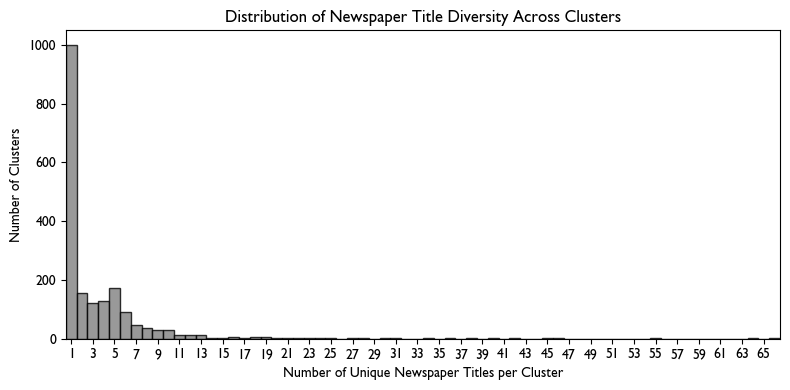

Saved: overall_stats/title_diversity_hist.png
Saved: overall_stats/title_diversity_hist_counts.csv


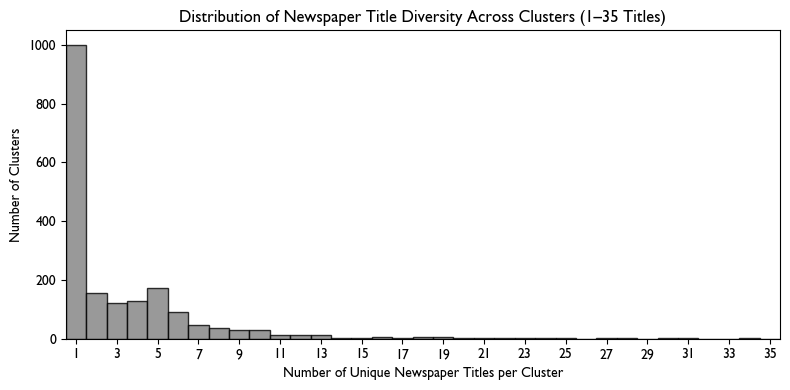

Saved: overall_stats/title_diversity_hist_zoom_35.png
Saved: overall_stats/title_diversity_hist_zoom_35_counts.csv


In [21]:
CLUSTERS_PATH = Path("clusters_min_5.json")
METADATA_PATH = Path("metadata.json")

STATS_DIR = Path("overall_stats")
STATS_DIR.mkdir(parents=True, exist_ok=True)

with open(CLUSTERS_PATH, "r") as f:
    clusters = json.load(f)

clusters = {str(k): v for k, v in clusters.items() if str(k) != "0"}
print(f"Clusters loaded (excluding 0): {len(clusters)}")

with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

id_to_newspaper = {}
for item in metadata:
    img_id = item.get("id")
    paper = item.get("newspaper")
    if img_id and paper:
        id_to_newspaper[img_id] = paper

print(f"Metadata items loaded: {len(metadata)}")
print(f"Lookup keys (image_id): {len(id_to_newspaper)}")

rows = []
missing_newspaper = 0

for cid, files in clusters.items():
    papers = set()

    for img_id in files:
        p = id_to_newspaper.get(img_id)
        if p:
            papers.add(p)
        else:
            missing_newspaper += 1

    rows.append({
        "cluster_id": str(cid),
        "n_files": len(files),
        "n_unique_titles": len(papers),
        "titles": sorted(papers),
    })

cluster_title_df = pd.DataFrame(rows)

print("Per-cluster title diversity computed.")
print("Total clusters:", len(cluster_title_df))
print("Missing newspaper lookups (image-level):", missing_newspaper)

cluster_title_csv = STATS_DIR / "cluster_title_diversity_per_cluster.csv"
cluster_title_df.drop(columns=["titles"]).to_csv(cluster_title_csv, index=False)
print("Saved:", cluster_title_csv)

cluster_title_df["spans_multiple"] = np.where(cluster_title_df["n_unique_titles"] >= 2, "multiple", "single")

tab1 = (
    cluster_title_df
    .groupby("spans_multiple", as_index=False)
    .agg(n_cluster=("cluster_id", "count"))
)
tab1["pct_clusters"] = (tab1["n_cluster"] / tab1["n_cluster"].sum() * 100).round(2)

tab1 = tab1.set_index("spans_multiple").reindex(["single", "multiple"]).reset_index()

display(tab1)

tab1_path = STATS_DIR / "title_diversity_spans_multiple_table.csv"
tab1.to_csv(tab1_path, index=False)
print("Saved:", tab1_path)

top10_titles = (
    cluster_title_df
    .sort_values(["n_unique_titles", "n_files"], ascending=[False, False])
    .loc[:, ["cluster_id", "n_files", "n_unique_titles", "titles"]]
    .head(10)
)

display(top10_titles)

top10_path = STATS_DIR / "clusters_most_titles_top10.csv"
top10_titles.drop(columns=["titles"]).to_csv(top10_path, index=False)
print("Saved:", top10_path)

vals = cluster_title_df["n_unique_titles"].values
max_titles = int(np.nanmax(vals)) if len(vals) else 1
bins = np.arange(0.5, max_titles + 1.5, 1.0)

fig = plt.figure(figsize=(8, 4))

plt.hist(
    vals,
    bins=bins,
    color="gray",
    edgecolor="black",
    alpha=0.8
)

tick_positions = list(range(1, max_titles + 1, 2))
plt.xticks(tick_positions)

plt.margins(x=0)
plt.xlabel("Number of Unique Newspaper Titles per Cluster")
plt.ylabel("Number of Clusters")
plt.title("Distribution of Newspaper Title Diversity Across Clusters")

plt.tight_layout()
plt.show()

hist_path = STATS_DIR / "title_diversity_hist.png"
fig.savefig(hist_path, dpi=300, bbox_inches="tight")
print("Saved:", hist_path)

counts, edges = np.histogram(vals, bins=bins)
bin_labels = [str(int(edges[i] + 0.5)) for i in range(len(counts))]
hist_counts_df = pd.DataFrame({"n_unique_titles": bin_labels, "n_clusters": counts.astype(int)})

hist_counts_path = STATS_DIR / "title_diversity_hist_counts.csv"
hist_counts_df.to_csv(hist_counts_path, index=False)
print("Saved:", hist_counts_path)

zoom_max = 35
vals_zoom = vals[vals <= zoom_max]
bins_zoom = np.arange(0.5, zoom_max + 1.5, 1.0)

fig_zoom = plt.figure(figsize=(8, 4))

plt.hist(
    vals_zoom,
    bins=bins_zoom,
    color="gray",
    edgecolor="black",
    alpha=0.8
)

tick_positions_zoom = list(range(1, zoom_max + 1, 2))
plt.xticks(tick_positions_zoom)

plt.margins(x=0)
plt.xlim(0.5, zoom_max + 0.5)
plt.xlabel("Number of Unique Newspaper Titles per Cluster")
plt.ylabel("Number of Clusters")
plt.title("Distribution of Newspaper Title Diversity Across Clusters (1–35 Titles)")

plt.tight_layout()
plt.show()

hist_zoom_path = STATS_DIR / "title_diversity_hist_zoom_35.png"
fig_zoom.savefig(hist_zoom_path, dpi=300, bbox_inches="tight")
print("Saved:", hist_zoom_path)

counts_zoom, edges_zoom = np.histogram(vals_zoom, bins=bins_zoom)
bin_labels_zoom = [str(int(edges_zoom[i] + 0.5)) for i in range(len(counts_zoom))]
hist_counts_zoom_df = pd.DataFrame({"n_unique_titles": bin_labels_zoom, "n_clusters": counts_zoom.astype(int)})

hist_counts_zoom_path = STATS_DIR / "title_diversity_hist_zoom_35_counts.csv"
hist_counts_zoom_df.to_csv(hist_counts_zoom_path, index=False)
print("Saved:", hist_counts_zoom_path)